# What is Data Preprocessing?

Data preprocessing means cleaning and preparing raw data before using it in machine learning.
It makes the data:

    Accurate and consistent

    Easier to analyze

    Suitable for model training

Example: If your dataset has missing values or wrong data, the model will give wrong predictions. So, we must fix the data first.

# Steps in Data Preprocessing

### Step 1: Import Libraries and Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv('/content/diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


    pandas → to handle data

    numpy → for math operations

    matplotlib / seaborn → for graphs

    sklearn → for preprocessing tools

### Step 2: Check Data Info and Missing Values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:

df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


    =>
    Column names
    Data types
    Missing values

    If values are missing, we can fill them or remove them.

### Step 3: Describe Data & Detect Outliers

In [ ]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


    Gives mean, min, max, etc.

    To see outliers, use boxplots

<Axes: ylabel='Insulin'>

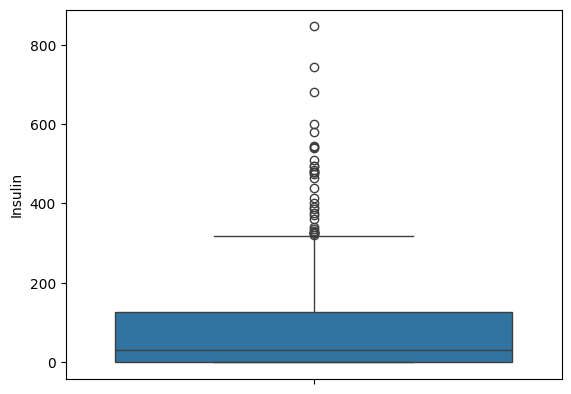

In [ ]:
sns.boxplot(df['Insulin'])


    Outliers are extreme values that don’t fit the pattern (for example, someone’s age = 200).

### Step 4: Remove Outliers (IQR Method)

    IQR = Q3 – Q1

    If a value is less than (Q1 – 1.5 × IQR) or
    more than (Q3 + 1.5 × IQR), it’s an outlier.

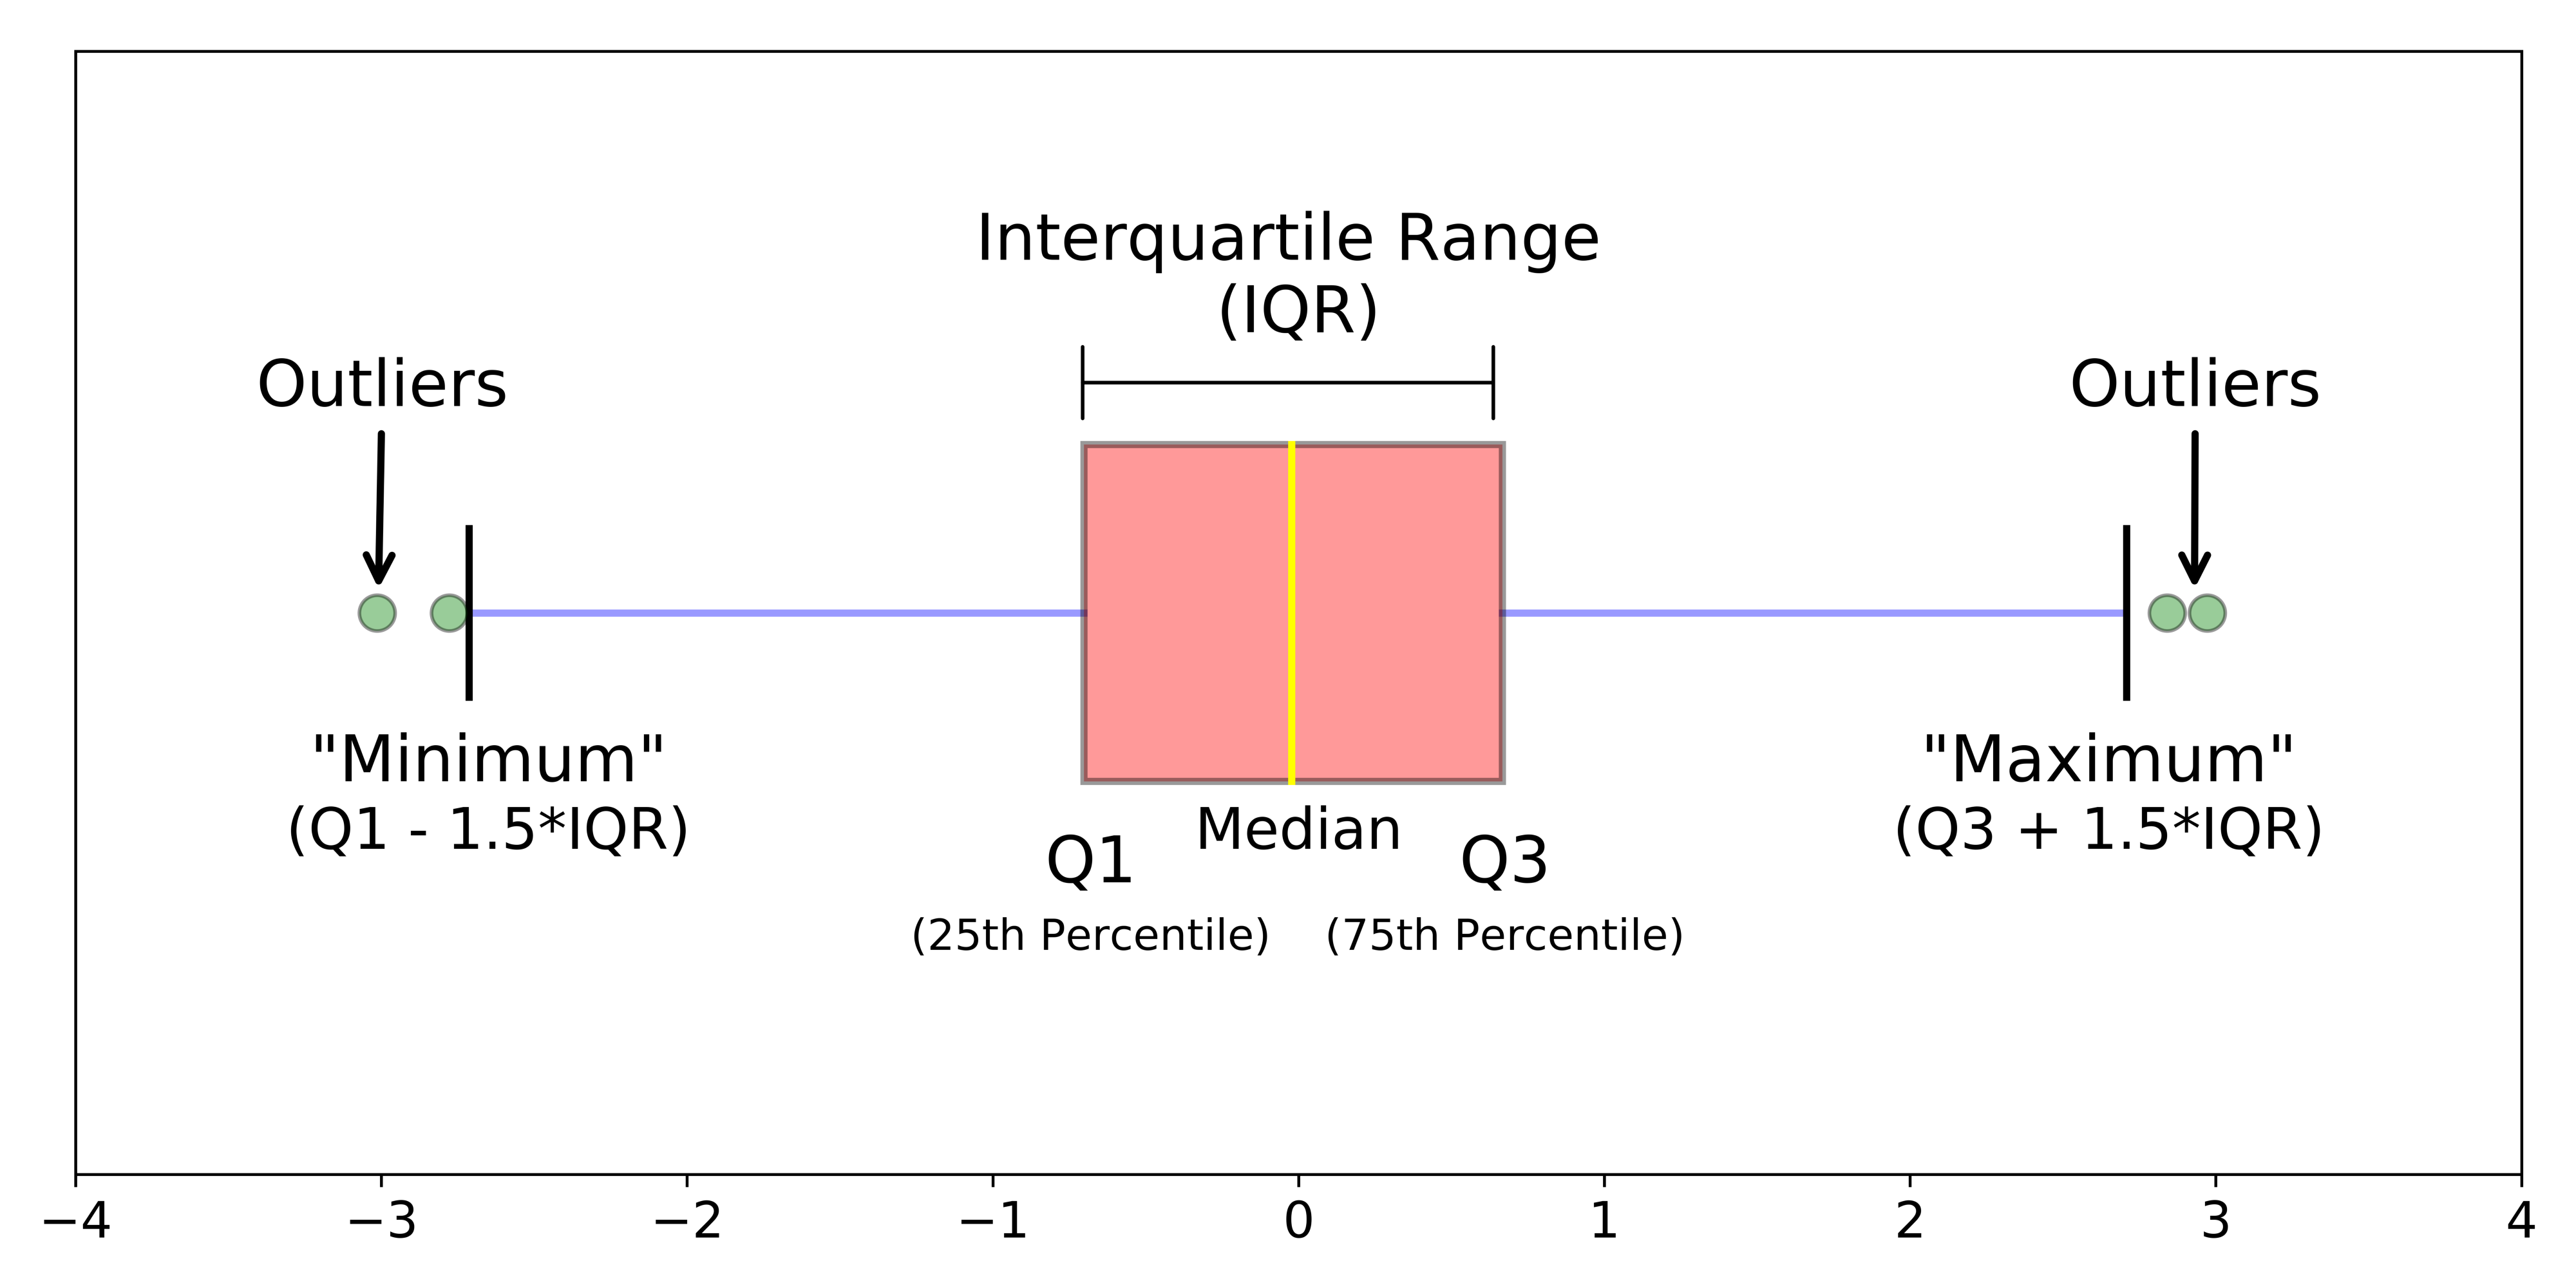

In [ ]:
q1, q3 = np.percentile(df['Insulin'], [25,75])
iqr = q3 - q1

print(iqr)

127.25


In [ ]:

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

print(upper,lower)

318.125 -190.875


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:

df = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,3.841962,119.182561,68.990463,19.985014,62.328338,31.854087,0.466918,33.185286,0.339237
std,3.383143,31.266437,19.613487,15.951788,79.132557,7.919395,0.322066,11.714824,0.473773
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.100000,0.243250,24.000000,0.000000
50%,3.000000,115.000000,72.000000,22.000000,0.000000,32.000000,0.368000,29.000000,0.000000
75%,6.000000,137.000000,80.000000,32.000000,115.000000,36.400000,0.613750,40.750000,1.000000
max,17.000000,199.000000,122.000000,99.000000,318.000000,67.100000,2.420000,81.000000,1.000000


(array([384.,  56.,  74.,  62.,  50.,  45.,  27.,  14.,  15.,   7.]),
 array([  0. ,  31.8,  63.6,  95.4, 127.2, 159. , 190.8, 222.6, 254.4,
        286.2, 318. ]),
 <BarContainer object of 10 artists>)

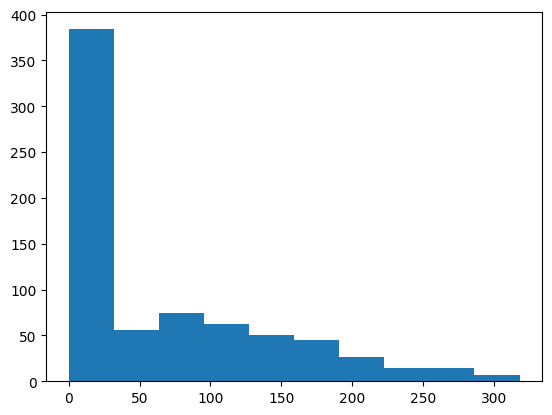

In [ ]:
plt.hist(df['Insulin'])

<Axes: ylabel='Insulin'>

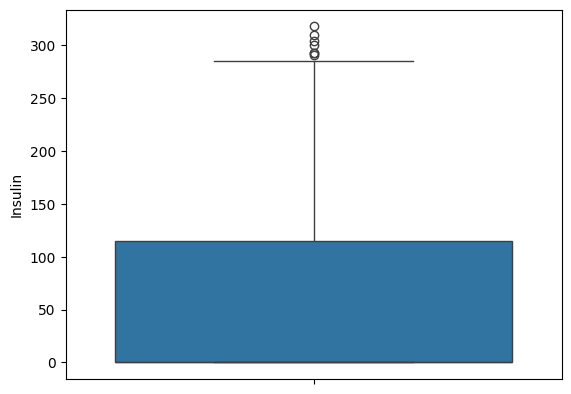

In [ ]:
sns.boxplot(df['Insulin'])


In [ ]:
q1, q3 = np.percentile(df['Insulin'], [25,75])

iqr=q3-q1
print(iqr)

115.0


In [ ]:
lower_b=q1-1.5*iqr
upper_b=q3+1.5*iqr

print(lower_b,upper_b)

-172.5 287.5


### Step 5: Check Correlation

We use a heatmap to see how features are related:

Correlation means the relationship or connection between two variables.
It shows how strongly and in what direction one variable changes with another.

| Type                     | Description                                       | Example                  |
| ------------------------ | ------------------------------------------------- | ------------------------ |
| **Positive Correlation** | Both variables increase or decrease together.     | Height ↑ → Weight ↑      |
| **Negative Correlation** | One variable increases while the other decreases. | Speed ↑ → Travel time ↓  |
| **Zero Correlation**     | No relation between variables.                    | Shoe size ↔ Intelligence |


Correlation Coefficient (r)

| Value of r | Meaning                      |
| ---------- | ---------------------------- |
| +1         | Perfect Positive Correlation |
| 0          | No Correlation               |
| -1         | Perfect Negative Correlation |


Example:

    r = 0.9 → strong positive relation

    r = -0.8 → strong negative relation

    r = 0.1 → very weak relation

In [ ]:
corr = df.corr()
display(corr)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.145973,0.141183,-0.086904,-0.097015,0.022434,-0.036690,0.540206,0.223300
Glucose,0.145973,1.000000,0.157764,0.012172,0.219678,0.212414,0.113037,0.277492,0.464128
BloodPressure,0.141183,0.157764,1.000000,0.204248,0.104340,0.281522,0.039816,0.241986,0.064360
SkinThickness,-0.086904,0.012172,0.204248,1.000000,0.486500,0.379985,0.173589,-0.122144,0.054106
Insulin,-0.097015,0.219678,0.104340,0.486500,1.000000,0.199290,0.186657,-0.098004,0.088944
BMI,0.022434,0.212414,0.281522,0.379985,0.199290,1.000000,0.143219,0.047741,0.297225
DiabetesPedigreeFunction,-0.036690,0.113037,0.039816,0.173589,0.186657,0.143219,1.000000,0.042365,0.183005
Age,0.540206,0.277492,0.241986,-0.122144,-0.098004,0.047741,0.042365,1.000000,0.231023
Outcome,0.223300,0.464128,0.064360,0.054106,0.088944,0.297225,0.183005,0.231023,1.000000


<Axes: >

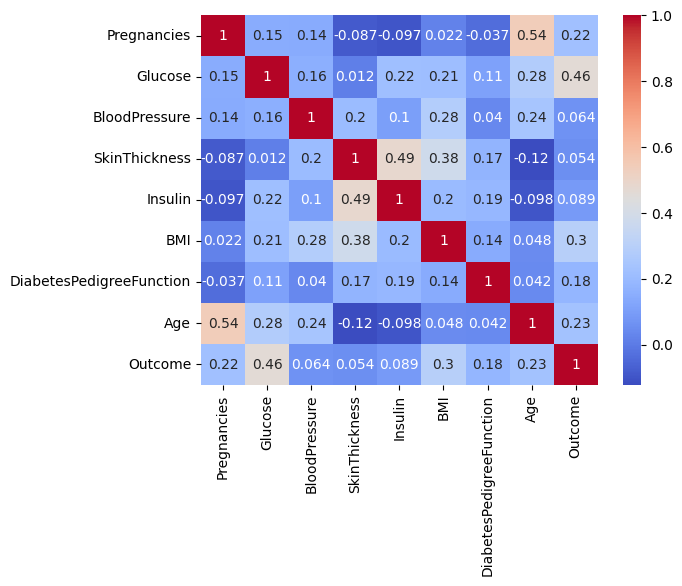

In [ ]:

sns.heatmap(corr, annot=True, cmap='coolwarm')

# If correlation is high, it means the two columns are related.


### Step 6: Check Target Balance

We must check if target classes are balanced (example: 500 diabetic, 500 non-diabetic).

([<matplotlib.patches.Wedge at 0x7804f2b5d520>,
 [Text(-0.5322380277630436, 0.9626643661229525, 'Diabetes'),
  Text(0.5322383414388807, -0.9626641926977391, 'No Diabetes')],
 [Text(-0.29031165150711463, 0.5250896542488831, '66.1%'),
  Text(0.29031182260302585, -0.5250895596533122, '33.9%')])

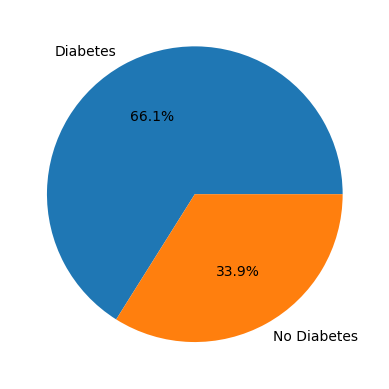

In [ ]:
plt.pie(df['Outcome'].value_counts(), labels=['Diabetes','No Diabetes'], autopct='%0.1f%%')

#If data is unbalanced, the model may be biased.

In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,485
1,249


### Step 7: Split Features and Target

In [ ]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# X - input features

# y - output/target value

display(X)
display(y)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


### Step 8: Feature Scaling

    Feature scaling means adjusting the values of features (columns) so that they all stay within a similar range or scale.

It helps make sure that no single feature dominates others just because it has larger values.

Why is Scaling Needed?

| Feature | Example Range    |
| ------- | ---------------- |
| Age     | 0 – 100          |
| Salary  | 5,000 – 1,00,000 |
| Height  | 120 – 200        |


When to Use Feature Scaling

Scaling is needed for algorithms that depend on distance or gradient:

    K-Nearest Neighbors (KNN)

    Support Vector Machine (SVM)

    K-Means Clustering

    Gradient Descent based models (Logistic Regression, Neural Networks)

Scaling is not needed for algorithms that are tree-based:

    Decision Trees

    Random Forest

    XGBoost


Types of Feature Scaling

There are two main types of scaling methods used in ML:

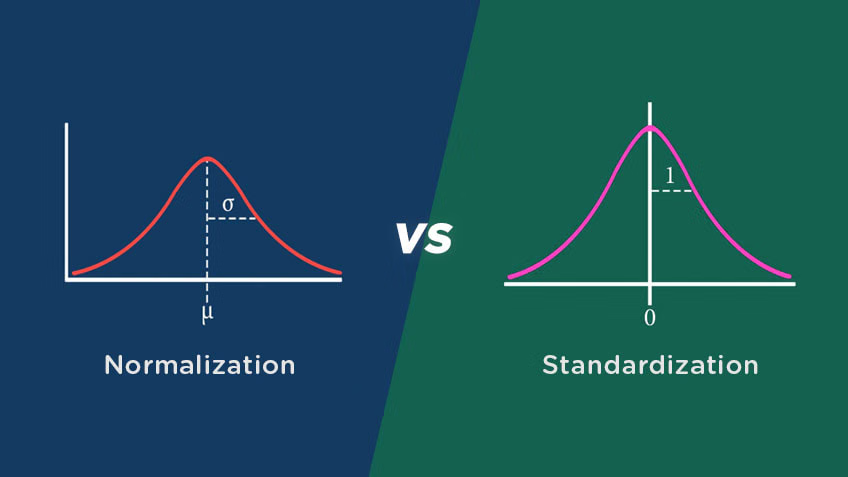

1. Normalization (0–1 range):

    Converts data to a range between 0 and 1.

    Keeps the original shape of the distribution.

Use when:

    You know minimum and maximum values.

    Data is not normally distributed (skewed data).

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

normal_df=pd.DataFrame(X_norm)
display(normal_df)

,0,1,2,3,4,5,6,7
0,0.352941,0.743719,0.590164,0.353535,0.000000,0.500745,0.234415,0.483333
1,0.058824,0.427136,0.540984,0.292929,0.000000,0.396423,0.116567,0.166667
2,0.470588,0.919598,0.524590,0.000000,0.000000,0.347243,0.253629,0.183333
3,0.058824,0.447236,0.540984,0.232323,0.295597,0.418778,0.038002,0.000000
4,0.000000,0.688442,0.327869,0.353535,0.528302,0.642325,0.943638,0.200000
...,...,...,...,...,...,...,...,...
729,0.588235,0.507538,0.622951,0.484848,0.566038,0.490313,0.039710,0.700000
730,0.117647,0.613065,0.573770,0.272727,0.000000,0.548435,0.111870,0.100000
731,0.294118,0.608040,0.590164,0.232323,0.352201,0.390462,0.071307,0.150000
732,0.058824,0.633166,0.491803,0.000000,0.000000,0.448584,0.115713,0.433333


2. Standardization (mean = 0, std = 1):

    Converts data to have mean = 0 and standard deviation = 1.

    The result can have negative values too.

Use when:

    Data is normally distributed.

    You want to remove the effect of units (kg, cm, ₹ etc.)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print(X_std)

[[ 0.63831459  0.92230173  0.15354684 ...  0.22061072  0.49738548
   1.43631516]
 [-0.84060873 -1.09401241 -0.15257371 ... -0.66389796 -0.36016635
  -0.18666744]
 [ 1.22988392  2.04247626 -0.25461389 ... -1.08088062  0.63720371
  -0.1012473 ]
 ...
 [ 0.34252992  0.0581671   0.15354684 ... -0.71444131 -0.68951596
  -0.27208757]
 [-0.84060873  0.21819203 -0.45869426 ... -0.22164362 -0.36638049
   1.18005475]
 [-0.84060873 -0.83797252  0.05150666 ... -0.18373611 -0.47202093
  -0.87002853]]


In [ ]:
Standard_df=pd.DataFrame(X_std)
Standard_df.describe()

,0,1,2,3,4,5,6,7
count,7.340000e+02,7.340000e+02,7.340000e+02,7.340000e+02,7.340000e+02,7.340000e+02,7.340000e+02,7.340000e+02
mean,-5.324230e-17,2.178094e-17,-3.630157e-17,4.840209e-17,-9.680419e-18,-4.150480e-16,2.420105e-18,1.960285e-16
std,1.000682e+00,1.000682e+00,1.000682e+00,1.000682e+00,1.000682e+00,1.000682e+00,1.000682e+00,1.000682e+00
min,-1.136393e+00,-3.814436e+00,-3.519900e+00,-1.253693e+00,-7.881818e-01,-4.025031e+00,-1.208397e+00,-1.040869e+00
25%,-8.406087e-01,-6.459426e-01,-3.566541e-01,-1.253693e+00,-7.881818e-01,-6.007188e-01,-6.949533e-01,-7.846084e-01
50%,-2.490394e-01,-1.338628e-01,1.535468e-01,1.264034e-01,-7.881818e-01,1.843731e-02,-3.073461e-01,-3.575077e-01
75%,6.383146e-01,5.702469e-01,5.617076e-01,7.537199e-01,6.660669e-01,5.744142e-01,4.562168e-01,6.461789e-01
max,3.891946e+00,2.554556e+00,2.704551e+00,4.956740e+00,3.233132e+00,4.453617e+00,6.068365e+00,4.084339e+00


| Without Scaling                                                      | After Normalization                                                                             | After Standardization                                                                                           |
| -------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------- |
| ![Unscaled](https://editor.analyticsvidhya.com/uploads/353241.1.jpg) | ![MinMax](https://vitalflux.com/wp-content/uploads/2023/12/standard-scaler-vs-minmaxscaler.png) | ![Standard](https://www.simplilearn.com/ice9/free_resources_article_thumb/Normalization_vs_Standardization.jpg) |


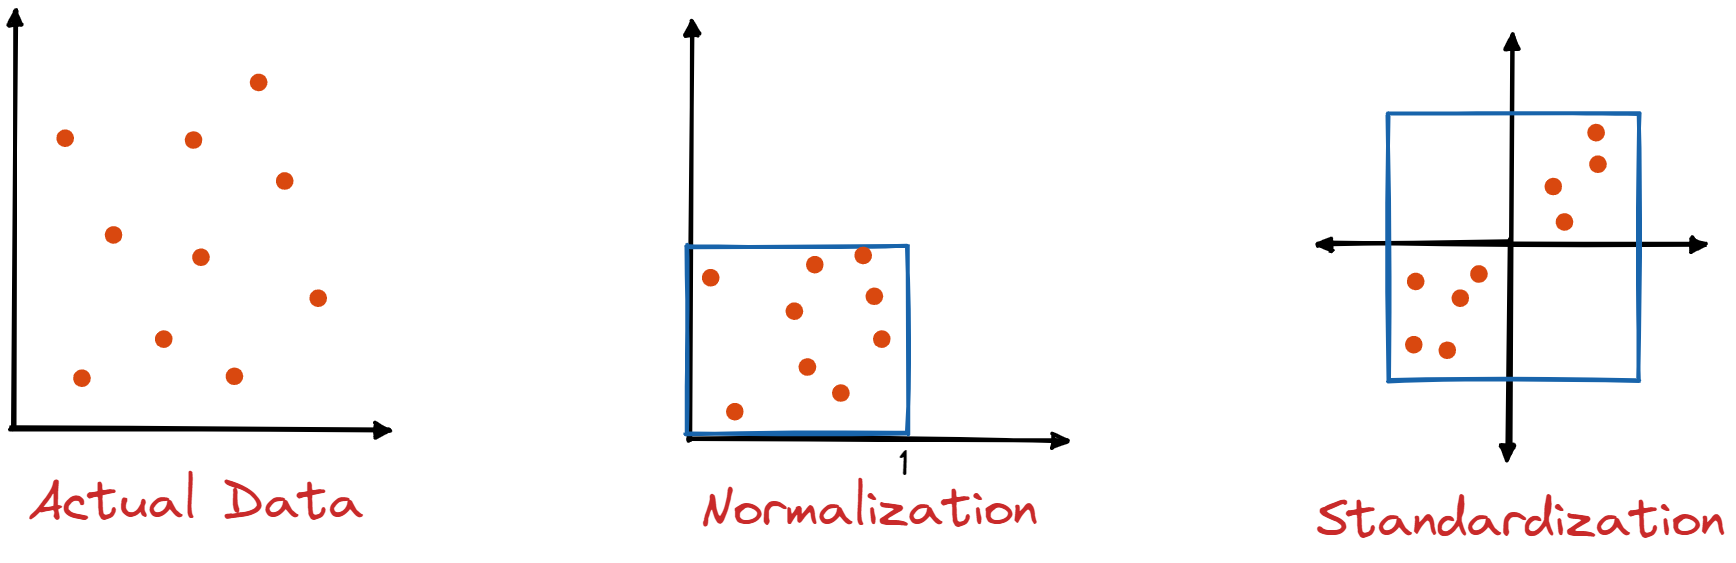

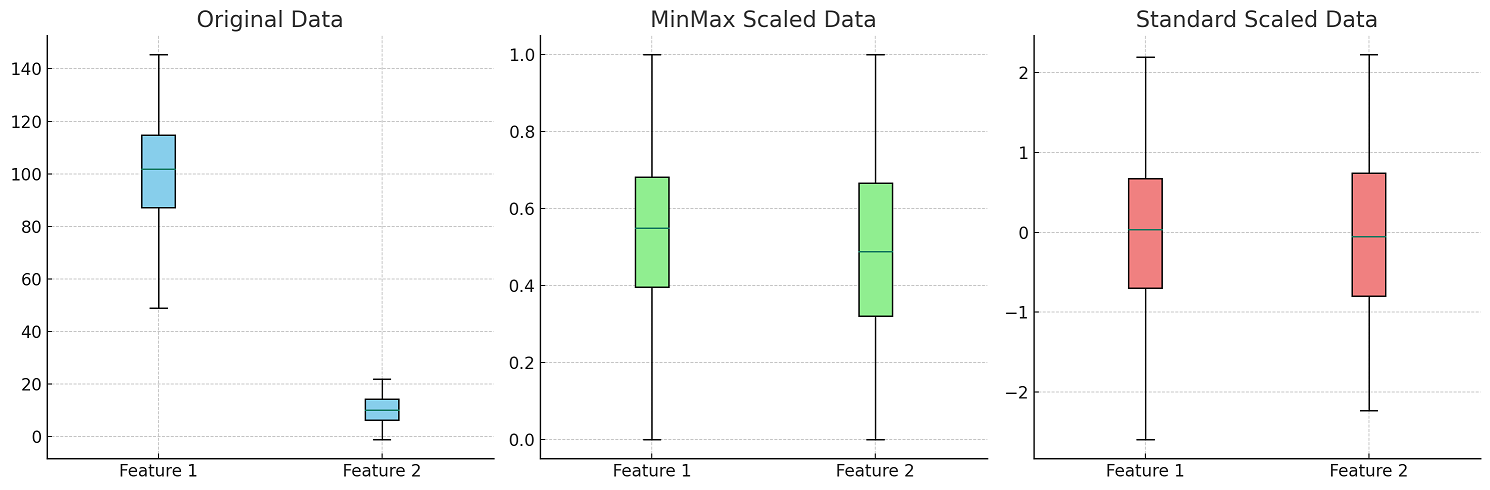

Benefits of Feature Scaling

    Speeds up Gradient Descent training

    Improves model accuracy

    Prevents bias due to large values

    Helps in faster convergence

    Makes data comparable across features

### Why Preprocessing is Important

    

*   Makes data clean and consistent
*   Helps model learn better
*   Removes noise and wrong data
*   Speeds up model training
*   Improves accuracy



    

    

    
    

Quick Summary

| Step | Task                  | Tool/Method                   |
| ---- | --------------------- | ----------------------------- |
| 1    | Load data             | pandas                        |
| 2    | Check missing values  | `df.isnull().sum()`           |
| 3    | Detect outliers       | boxplot                       |
| 4    | Remove outliers       | IQR method                    |
| 5    | Check correlation     | heatmap                       |
| 6    | Check target balance  | pie chart                     |
| 7    | Split features/target | `X`, `y`                      |
| 8    | Scale features        | MinMaxScaler / StandardScaler |
